<a href="https://colab.research.google.com/github/lpodina/conformal_pinns/blob/main/MTRBad_model_Conformal_PINNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import warnings
from scipy.integrate import odeint
from matplotlib import style
import numpy as np

warnings.filterwarnings('ignore')

np.random.seed(1234)

In [ ]:

all_true_alphas = np.arange(0.0,1.0,1.0/100.0)
#all_inferred_alphas = np.random.uniform(0.0,1.0,100)
all_inferred_alphas = np.where(all_true_alphas < 0.5,
                               np.random.normal(0.25, 0.25, 100),  # Distribution 1
                               np.random.normal(0.8, 0.05, 100)   # Distribution 2
                               )


Text(0, 0.5, 'Estimated alpha')

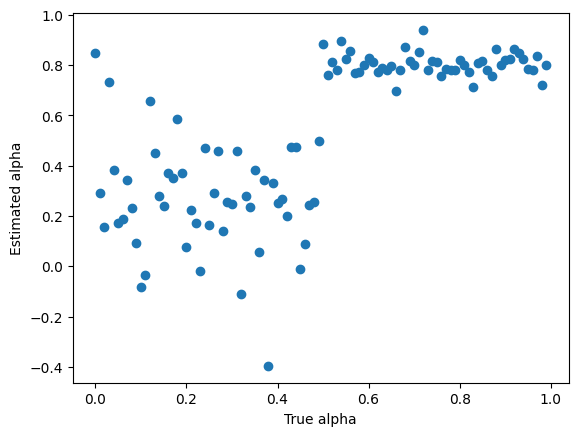

In [ ]:
plt.plot(all_true_alphas, all_inferred_alphas,'o')
plt.xlabel("True alpha")
plt.ylabel("Estimated alpha")

In [ ]:
from sklearn.linear_model import LinearRegression
mask_less_than_0_5 = all_true_alphas < 0.5

# Create subsets of the data
X_less_than_0_5 = all_true_alphas[mask_less_than_0_5].reshape(-1, 1)
y_less_than_0_5 = all_inferred_alphas[mask_less_than_0_5]

X_greater_than_0_5 = all_true_alphas[~mask_less_than_0_5].reshape(-1, 1)
y_greater_than_0_5 = all_inferred_alphas[~mask_less_than_0_5]

# Fit linear models for each subset
model_less_than_0_5 = LinearRegression().fit(X_less_than_0_5, y_less_than_0_5)
model_greater_than_0_5 = LinearRegression().fit(X_greater_than_0_5, y_greater_than_0_5)

In [ ]:
# Make predictions using the fitted models
all_inferred_alphas_pred_less_than_0_5 = model_less_than_0_5.predict(X_less_than_0_5)
all_inferred_alphas_pred_greater_than_0_5 = model_greater_than_0_5.predict(X_greater_than_0_5)
all_inferred_alphas_pred = list(all_inferred_alphas_pred_less_than_0_5) + list(all_inferred_alphas_pred_greater_than_0_5)

len(true_alphas) =  100
len(inferred_alphas) =  100


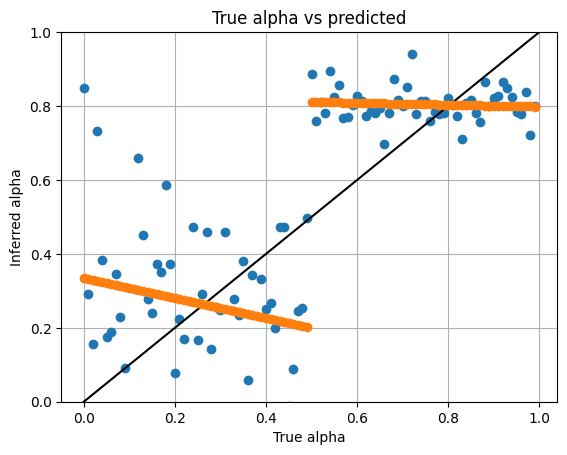

In [ ]:
print("len(true_alphas) = ",len(all_true_alphas))
print("len(inferred_alphas) = ",len(all_inferred_alphas))

plt.plot(all_true_alphas,all_inferred_alphas,'o')
plt.xlabel("True alpha")
plt.ylabel("Inferred alpha")
plt.ylim([0,1.0])
plt.gca().axline((0, 0), slope=1,c='k')
plt.title("True alpha vs predicted")

#plt.plot(X_less_than_0_5, all_inferred_alphas_pred_less_than_0_5, 'o', label="Predictions (alpha < 0.5)")
#plt.plot(X_greater_than_0_5, all_inferred_alphas_pred_greater_than_0_5, 'o', label="Predictions (alpha >= 0.5)")
plt.plot(all_true_alphas, all_inferred_alphas_pred, 'o', label="Predictions")

plt.grid()

In [ ]:
def non_conformity_func(y, y_hat):
  return np.abs(y - y_hat)

In [ ]:
'''
fresh_points_for_conformalizer_X = t_cal
fresh_points_for_conformalizer_y = N_cal
'''
fresh_points_for_conformalizer_X = np.array(all_true_alphas)
#fresh_points_for_conformalizer_y = np.array(all_inferred_alphas) # model predictions MTR - we don't have a model for alpha
fresh_points_for_conformalizer_y = np.array(all_inferred_alphas_pred)

# true values should be all_true_alphas


In [ ]:
alpha = 0.2 # miscoverage
sig_level_delta = 1 - alpha
calib_data, valid_data = {}, {}
n_calib = 80
#n_valid = fresh_points_for_conformalizer_X.shape[0] - n_calib
n_valid = 20

lower_bound, upper_bound, exact_coverage = sig_level_delta, (sig_level_delta + 1/(n_calib+1)), (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# To see how the relations for upper bound and the exact coverage are derived, see the following video:
# Uncertainty Quantification (4A): Implementing Split Conformal - Relation for Prediction Intervals


empirical_coverages_for_all_trials = []
#num_trials = 10000
num_trials = 10000

for trial_num in range(num_trials):
  # taking valid_data['y'] out because one cannot say whether it is predictions of the first model or second.
  # Our objective is to conformalize one model using calibration errors from both models.

  calib_data['X'], valid_data['X'], calib_data['y'], _ = train_test_split(
      fresh_points_for_conformalizer_X,
      fresh_points_for_conformalizer_y,
      test_size=n_valid
      )

  valid_data['X'] = valid_data['X'][valid_data['X'] < 0.5]

  valid_data['y'] = model_less_than_0_5.predict(valid_data['X'].reshape(-1, 1))

  scores_calib = non_conformity_func(calib_data['X'], calib_data['y'])
  which_quantile = np.ceil((sig_level_delta)*(n_calib + 1))/n_calib

  q_hat = np.quantile(scores_calib, which_quantile, method='lower')

  y_lower, y_pred, y_upper = valid_data['y'] - q_hat, valid_data['y'], valid_data['y'] + q_hat

  #y_lower, y_upper = y_hat_valid - q_hat, y_hat_valid + q_hat


  # valid_data['X'] also serves as the true value of alpha to which to compare
  fraction_within_bounds = np.mean((valid_data['X'] >= y_lower) & (valid_data['X'] <= y_upper))
  empirical_coverage = fraction_within_bounds
  empirical_coverages_for_all_trials.append(empirical_coverage)


In [ ]:
def running_average(arr):
  cumsum = np.cumsum(arr)
  indices = np.arange(1, len(arr) + 1)
  running_avg = cumsum / indices
  return running_avg

In [ ]:
running_averages = running_average(empirical_coverages_for_all_trials)

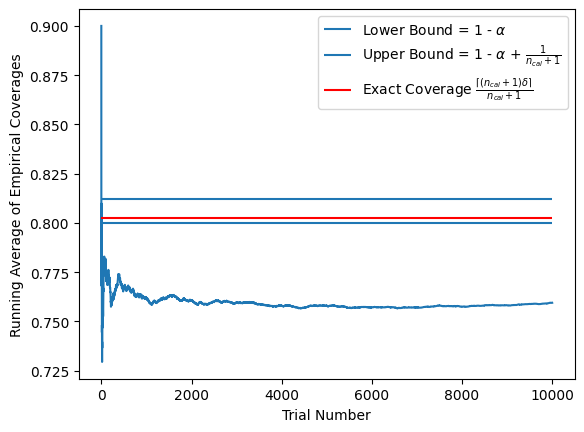

In [ ]:
plt.plot(running_averages)
plt.hlines(lower_bound, 0, num_trials, label=r'Lower Bound = 1 - $\alpha$')
plt.hlines(upper_bound, 0, num_trials, label=r'Upper Bound = 1 - $\alpha$ + $\frac{1}{n_{cal}+1}$')
plt.hlines(exact_coverage, 0, num_trials, label=r'Exact Coverage $\frac{\lceil (n_{cal}+1)\delta \rceil}{n_{cal}+1}$', color='r')
# (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# \frac{\lceil (n+1) \cdot \text{sig\_level} \rceil}{n+1}
plt.xlabel('Trial Number')
plt.ylabel('Running Average of Empirical Coverages')
plt.legend()
#plt.ylim(0.899, 0.903)

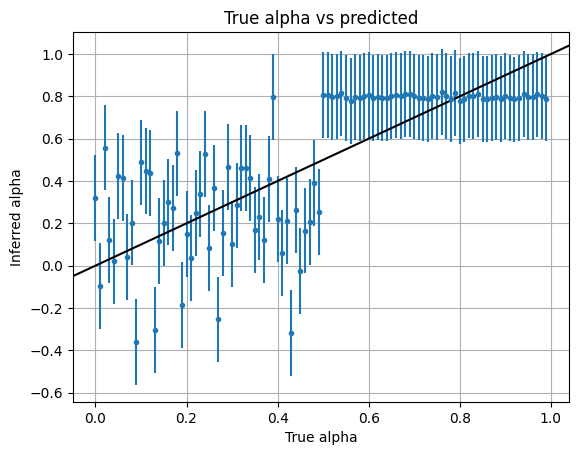

In [ ]:
plt.errorbar(all_true_alphas,all_inferred_alphas,yerr=q_hat,fmt='.')
plt.xlabel("True alpha")
plt.ylabel("Inferred alpha")
plt.gca().axline((0, 0), slope=1,c='k')
plt.title("True alpha vs predicted")
plt.grid()